# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [2]:
df_meters = pd.read_parquet("data/meters.parquet")
df_registry = pd.read_csv("data/registry.csv")

print(df_meters.shape, df_registry.shape)
print(df_meters.dtypes, "\n")
print(df_registry.dtypes)
df_meters.head()

(526534, 4) (800, 7)
meter_id                      str
ts                 datetime64[us]
consumption_kwh           float64
record_ts          datetime64[us]
dtype: object 

meter_id              str
customer_type         str
tariff                str
electric_heating    int64
connection_year     int64
years_connected     int64
district              str
dtype: object


,meter_id,ts,consumption_kwh,record_ts
0,UA100035,2026-01-05 00:00:00,0.9579,2026-01-05 00:02:50
1,UA100035,2026-01-05 01:00:00,0.8804,2026-01-05 01:13:09
2,UA100035,2026-01-05 02:00:00,0.8601,2026-01-05 02:05:54
3,UA100035,2026-01-05 03:00:00,0.9400,2026-01-05 03:06:26
4,UA100035,2026-01-05 04:00:00,1.0637,2026-01-05 04:09:21


## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [3]:
print("Опис числових колонок реєстру:")
print(df_registry.describe(), "\n")

# категорії, яких немає в описі
print("customer_type поза описом:", (~df_registry["customer_type"].isin(["household", "small_business", "industrial"])).sum())
print("tariff поза описом:", (~df_registry["tariff"].isin(["single", "dual_zone"])).sum())
print("electric_heating поза описом:", (~df_registry["electric_heating"].isin([0, 1])).sum())

# межі з опису
ts_ok = df_meters["ts"].between(pd.Timestamp("2026-01-05 00:00"), pd.Timestamp("2026-02-01 23:00"))
print("ts поза межами:", (~ts_ok).sum())
print("connection_year поза межами:", (~df_registry["connection_year"].between(1985, 2024)).sum())
print("years_connected поза межами:", (~df_registry["years_connected"].between(1, 41)).sum())

# кількість лічильників
print("лічильників у meters:", df_meters["meter_id"].nunique())
print("лічильників у registry:", df_registry["meter_id"].nunique())

Опис числових колонок реєстру:
       electric_heating  connection_year  years_connected
count        800.000000       800.000000        800.00000
mean           0.223750      2004.728750         20.77000
std            0.417017        11.603058         11.63836
min            0.000000      1985.000000          1.00000
25%            0.000000      1995.000000         10.00000
50%            0.000000      2004.000000         21.00000
75%            0.000000      2015.000000         31.00000
max            1.000000      2024.000000         41.00000 

customer_type поза описом: 0
tariff поза описом: 0
electric_heating поза описом: 0
ts поза межами: 0
connection_year поза межами: 0
years_connected поза межами: 0
лічильників у meters: 800
лічильників у registry: 800


## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [4]:
# D-E: зіпсовані номери лічильників
bad_id = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")
print("D-E: зіпсованих номерів:", bad_id.sum())
print(df_registry.loc[bad_id, "meter_id"].head().tolist())

df_registry["meter_id"] = df_registry["meter_id"].str.strip().str.lstrip("0")
print("D-E після виправлення:", (~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")).sum())

# D-F: різне написання районів
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
bad_district = ~df_registry["district"].isin(districts)
print("\nD-F: рядків з неправильним районом:", bad_district.sum())
print(df_registry.loc[bad_district, "district"].unique()[:10])

df_registry["district"] = df_registry["district"].str.strip().str.capitalize()
print("D-F після виправлення:", (~df_registry["district"].isin(districts)).sum())

D-E: зіпсованих номерів: 96
['UA102260 ', ' UA119161', '00UA152693', ' UA154552', '00UA154851']
D-E після виправлення: 0

D-F: рядків з неправильним районом: 80
<ArrowStringArray>
['Sviatoshyn ',       'PODIL',  'SOLOMIANKA',   'DARNYTSIA', 'Solomianka ',
  'Darnytsia ',     'Obolon ',  'solomianka',  'sviatoshyn',      'obolon']
Length: 10, dtype: str
D-F після виправлення: 0


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [5]:
rows_before = len(df_meters)
df = df_meters.merge(df_registry, on="meter_id", how="left", validate="m:1")

print("рядків до об'єднання:", rows_before)
print("рядків після об'єднання:", len(df))
print("рядків без атрибутів абонента:", df["customer_type"].isna().sum())
df.head()

рядків до об'єднання: 526534
рядків після об'єднання: 526534
рядків без атрибутів абонента: 0


,meter_id,ts,consumption_kwh,record_ts,customer_type,tariff,electric_heating,connection_year,years_connected,district
0,UA100035,2026-01-05 00:00:00,0.9579,2026-01-05 00:02:50,small_business,single,0,1989,37,Obolon
1,UA100035,2026-01-05 01:00:00,0.8804,2026-01-05 01:13:09,small_business,single,0,1989,37,Obolon
2,UA100035,2026-01-05 02:00:00,0.8601,2026-01-05 02:05:54,small_business,single,0,1989,37,Obolon
3,UA100035,2026-01-05 03:00:00,0.9400,2026-01-05 03:06:26,small_business,single,0,1989,37,Obolon
4,UA100035,2026-01-05 04:00:00,1.0637,2026-01-05 04:09:21,small_business,single,0,1989,37,Obolon


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [6]:
n_rows = len(df)
n_pairs = len(df[["meter_id", "ts"]].drop_duplicates())
print("D-C: рядків:", n_rows)
print("D-C: різних пар meter_id і ts:", n_pairs)
print("D-C: зайвих рядків:", n_rows - n_pairs)

df = df.sort_values("record_ts").drop_duplicates(["meter_id", "ts"], keep="last")
df = df.sort_values(["meter_id", "ts"]).reset_index(drop=True)
print("рядків після зняття повторів:", len(df))
print("повторів лишилось:", df.duplicated(["meter_id", "ts"]).sum())

D-C: рядків: 526534
D-C: різних пар meter_id і ts: 516311
D-C: зайвих рядків: 10223
рядків після зняття повторів: 516311
повторів лишилось: 0


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

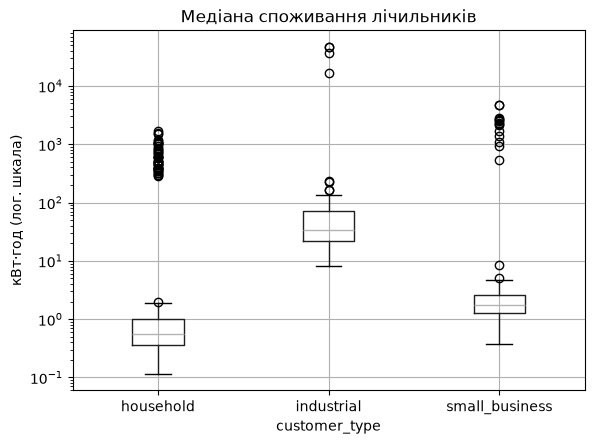

D-D: лічильників у Вт·год: 64
найбільше відношення серед решти: 6.31
найменше відношення серед Вт·год: 282.03
рядків поза межами споживання: 0


In [7]:
meter_median = df.groupby("meter_id")["consumption_kwh"].median()
meter_type = df.groupby("meter_id")["customer_type"].first()
type_median = df.groupby("customer_type")["consumption_kwh"].median()
ratio = meter_median / meter_type.map(type_median)

# графік медіан лічильників за типом абонента
medians = pd.DataFrame({"median_kwh": meter_median, "customer_type": meter_type})
medians.boxplot(column="median_kwh", by="customer_type")
plt.yscale("log")
plt.title("Медіана споживання лічильників")
plt.suptitle("")
plt.ylabel("кВт·год (лог. шкала)")
plt.show()

wh_meters = ratio[ratio > 100].index
print("D-D: лічильників у Вт·год:", len(wh_meters))
print("найбільше відношення серед решти:", round(ratio[ratio <= 100].max(), 2))
if len(wh_meters) > 0:
    print("найменше відношення серед Вт·год:", round(ratio[ratio > 100].min(), 2))


df.loc[df["meter_id"].isin(wh_meters), "consumption_kwh"] /= 1000

min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
in_range = df["consumption_kwh"].between(df["customer_type"].map(min_kwh), df["customer_type"].map(max_kwh))
print("рядків поза межами споживання:", (~in_range).sum())

## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [8]:
period_end = pd.Timestamp("2026-02-01 23:00")
last_ts = df.groupby("meter_id")["ts"].max()
silence_hours = (period_end - last_ts) / pd.Timedelta(hours=1)

silent_mask = silence_hours > 48
silent = list(silence_hours[silent_mask].index)

print("D-A: замовклих лічильників:", len(silent))
print("найбільша тиша серед решти, год:", silence_hours[~silent_mask].max())
if len(silent) > 0:
    print("найменша тиша серед замовклих, год:", silence_hours[silent_mask].min())

D-A: замовклих лічильників: 48
найбільша тиша серед решти, год: 1.0
найменша тиша серед замовклих, год: 153.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

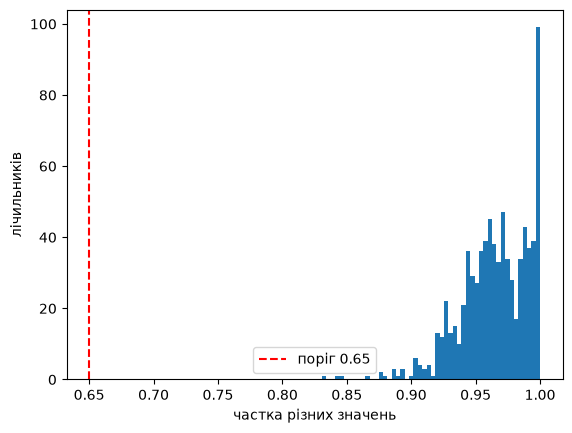

D-B: завмерлих лічильників: 0
найменша частка серед решти: 0.831


In [9]:
by_meter = df.groupby("meter_id")["consumption_kwh"]
unique_share = by_meter.nunique() / by_meter.size()

plt.hist(unique_share, bins=50)
plt.axvline(0.65, color="red", linestyle="--", label="поріг 0.65")
plt.xlabel("частка різних значень")
plt.ylabel("лічильників")
plt.legend()
plt.show()

frozen_mask = unique_share < 0.65
frozen = list(unique_share[frozen_mask].index)

print("D-B: завмерлих лічильників:", len(frozen))
print("найменша частка серед решти:", round(unique_share[~frozen_mask].min(), 3))
if len(frozen) > 0:
    print("найбільша частка серед завмерлих:", round(unique_share[frozen_mask].max(), 3))

## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [10]:
corr = df.select_dtypes("number").corr().abs()
print(corr.round(3), "\n")

copy_pairs = [(a, b, corr.loc[a, b]) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]
for a, b, value in copy_pairs:
    print(f"колонки-копії: {a} і {b}, |r| = {value:.4f}")

columns_to_drop = list({b for a, b, value in copy_pairs})
print("прибираємо:", columns_to_drop, "+ record_ts")

result = df.drop(columns=columns_to_drop + ["record_ts"])
print(result.columns.tolist())

                  consumption_kwh  electric_heating  connection_year  \
consumption_kwh             1.000             0.109            0.008   
electric_heating            0.109             1.000            0.019   
connection_year             0.008             0.019            1.000   
years_connected             0.006             0.020            0.999   

                  years_connected  
consumption_kwh             0.006  
electric_heating            0.020  
connection_year             0.999  
years_connected             1.000   

колонки-копії: connection_year і years_connected, |r| = 0.9991
прибираємо: ['years_connected'] + record_ts
['meter_id', 'ts', 'consumption_kwh', 'customer_type', 'tariff', 'electric_heating', 'connection_year', 'district']


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [11]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (516311, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [12]:
# TODO: homes — рядки result для домогосподарств без лічильників із silent і frozen
# кожну умову беріть у дужки: result[(умова 1) & ~(умова 2)]
homes = result[(result["customer_type"] == "household") & ~(result["meter_id"].isin(silent + frozen))]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x, y = per_meter[["electric_heating", "dual_zone"]], per_meter["kwh_per_day"]
model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")

лічильників: 511
a = 11.01, b₁ (опалення) = 14.23, b₂ (двозонний тариф) = 2.38, R² = 0.630
